In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
doc_sent = pd.read_csv("../data/output/DOC_SENT.csv", sep="|")
doc_sent.head()

,book_number,chapter,verse,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative,token_count
0,1,1,1,0.000000,0.100000,0.0,0.100000,0.100000,0.000000,0.000000,0.100000,0.100000,0.000000,10
1,1,1,2,0.034483,0.034483,0.0,0.068966,0.034483,0.034483,0.000000,0.034483,0.068966,0.034483,29
2,1,1,3,0.000000,0.090909,0.0,0.090909,0.090909,0.000000,0.000000,0.090909,0.090909,0.000000,11
3,1,1,4,0.058824,0.176471,0.0,0.176471,0.176471,0.058824,0.058824,0.176471,0.176471,0.058824,17
4,1,1,5,0.045455,0.045455,0.0,0.090909,0.045455,0.045455,0.000000,0.045455,0.045455,0.045455,22


In [15]:
lib = pd.read_csv("../data/archive/key_english.csv", sep=",")
lib.head()

,b,n,t,g
0,1,Genesis,OT,1
1,2,Exodus,OT,1
2,3,Leviticus,OT,1
3,4,Numbers,OT,1
4,5,Deuteronomy,OT,1


In [16]:
lib.columns = ["book_number", "book_name", "testament", "genre"]

lib.head()

,book_number,book_name,testament,genre
0,1,Genesis,OT,1
1,2,Exodus,OT,1
2,3,Leviticus,OT,1
3,4,Numbers,OT,1
4,5,Deuteronomy,OT,1


In [17]:
doc_sent = doc_sent.merge(lib, on="book_number", how="left")
doc_sent.head()

,book_number,chapter,verse,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative,token_count,book_name,testament,genre
0,1,1,1,0.000000,0.100000,0.0,0.100000,0.100000,0.000000,0.000000,0.100000,0.100000,0.000000,10,Genesis,OT,1
1,1,1,2,0.034483,0.034483,0.0,0.068966,0.034483,0.034483,0.000000,0.034483,0.068966,0.034483,29,Genesis,OT,1
2,1,1,3,0.000000,0.090909,0.0,0.090909,0.090909,0.000000,0.000000,0.090909,0.090909,0.000000,11,Genesis,OT,1
3,1,1,4,0.058824,0.176471,0.0,0.176471,0.176471,0.058824,0.058824,0.176471,0.176471,0.058824,17,Genesis,OT,1
4,1,1,5,0.045455,0.045455,0.0,0.090909,0.045455,0.045455,0.000000,0.045455,0.045455,0.045455,22,Genesis,OT,1


In [18]:
emo_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "sadness", "surprise", "trust",
    "positive", "negative"
]

book_sent = (
    doc_sent
    .groupby(["book_number", "book_name", "testament"])[emo_cols]
    .mean()
    .reset_index()
)

book_sent.head()

,book_number,book_name,testament,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative
0,1,Genesis,OT,0.008352,0.018713,0.010655,0.017280,0.022535,0.010256,0.006596,0.035766,0.047400,0.022831
1,2,Exodus,OT,0.012557,0.016544,0.018988,0.017968,0.012993,0.010912,0.004941,0.036855,0.049103,0.033872
2,3,Leviticus,OT,0.016402,0.012896,0.044706,0.025085,0.015400,0.020123,0.006017,0.052104,0.060992,0.056391
3,4,Numbers,OT,0.011990,0.014214,0.025588,0.016544,0.011737,0.013618,0.005332,0.046609,0.049820,0.038396
4,5,Deuteronomy,OT,0.016568,0.028758,0.028863,0.032389,0.029398,0.014697,0.007938,0.057065,0.071778,0.048105


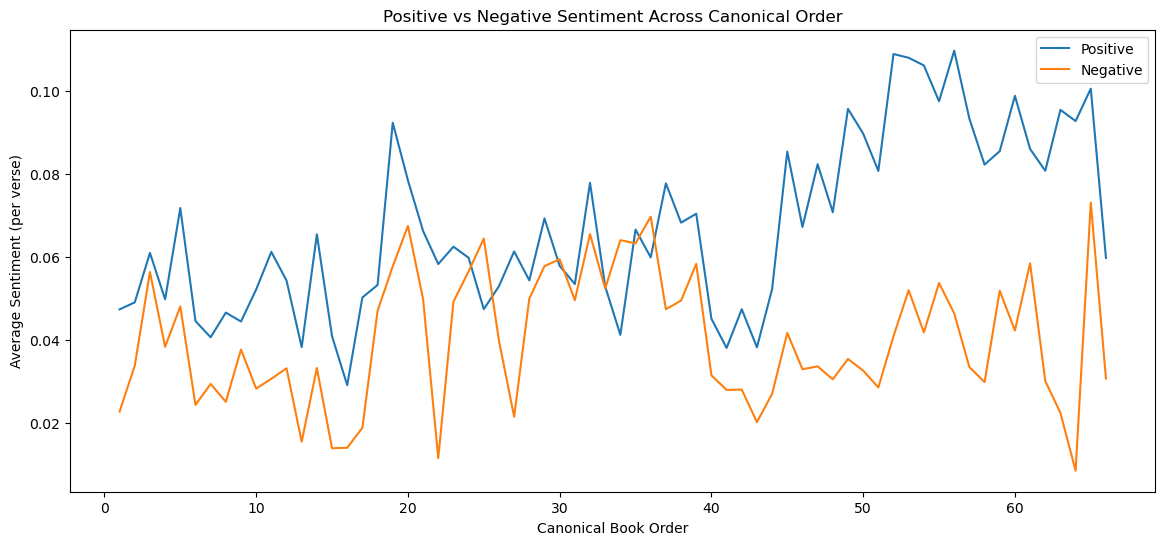

In [19]:
plt.figure(figsize=(14,6))

plt.plot(book_sent["book_number"], book_sent["positive"], label="Positive")
plt.plot(book_sent["book_number"], book_sent["negative"], label="Negative")

plt.xlabel("Canonical Book Order")
plt.ylabel("Average Sentiment (per verse)")
plt.title("Positive vs Negative Sentiment Across Canonical Order")
plt.legend()
plt.show()

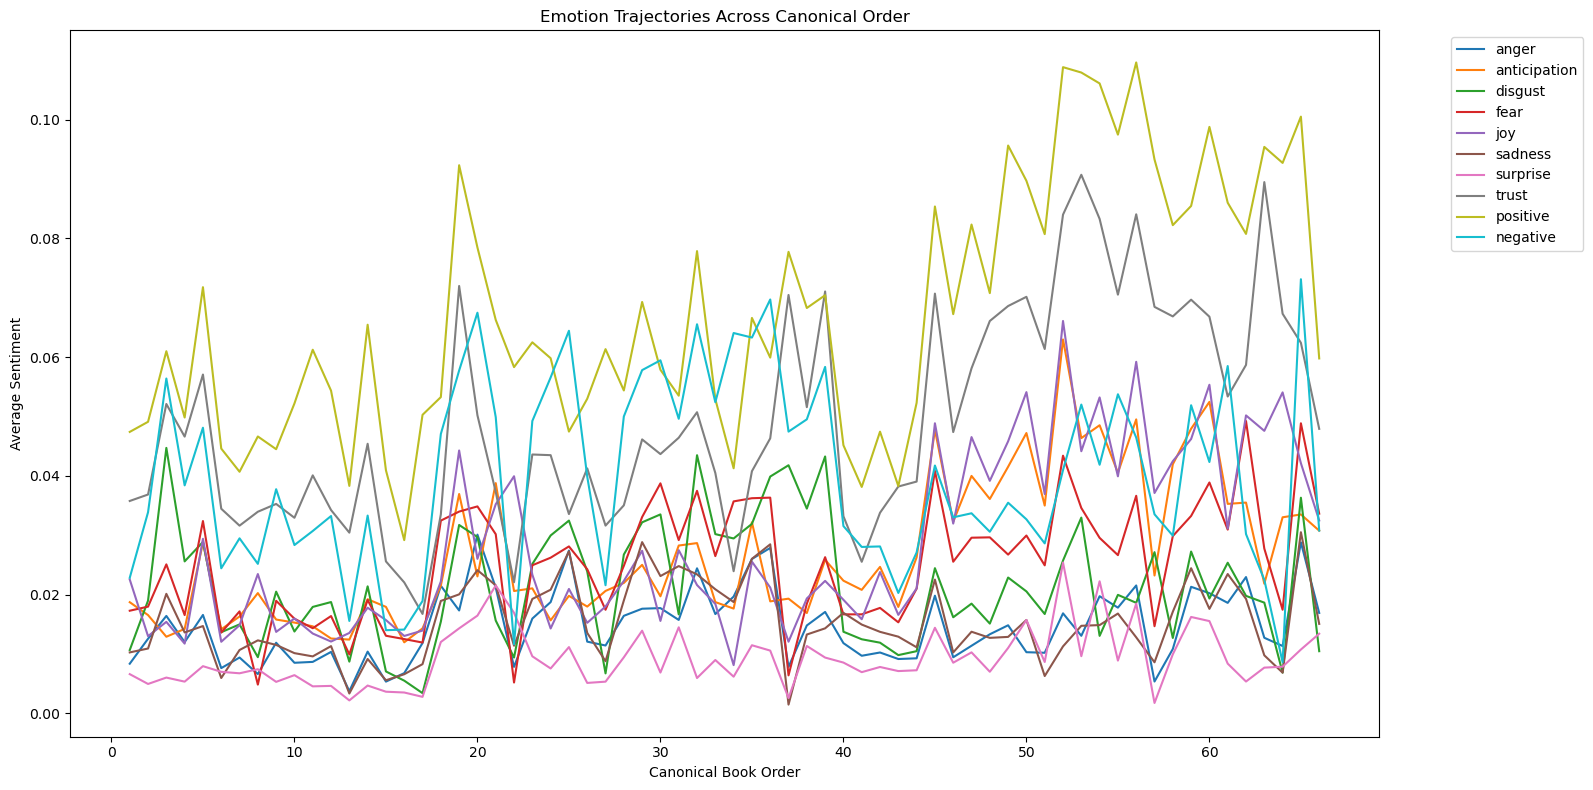

In [20]:
plt.figure(figsize=(16,8))

for col in emo_cols:
    plt.plot(book_sent["book_number"], book_sent[col], label=col)

plt.xlabel("Canonical Book Order")
plt.ylabel("Average Sentiment")
plt.title("Emotion Trajectories Across Canonical Order")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

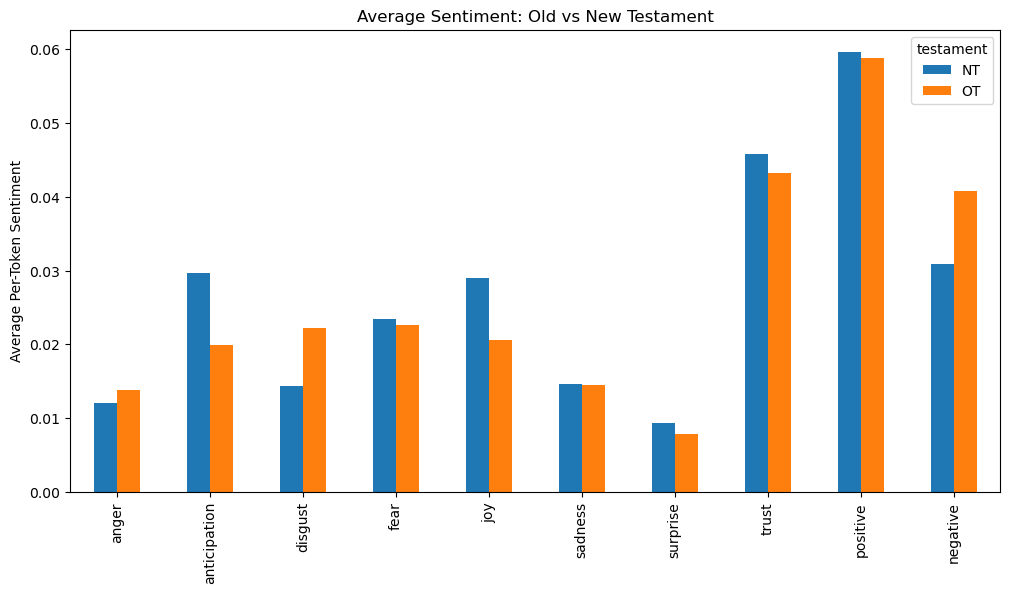

In [21]:
testament_avg = (
    doc_sent
    .groupby("testament")[emo_cols]
    .mean()
)

testament_avg.T.plot(kind="bar", figsize=(12,6))
plt.title("Average Sentiment: Old vs New Testament")
plt.ylabel("Average Per-Token Sentiment")
plt.show()

In [23]:
import plotly.graph_objects as go

In [24]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=book_sent["book_number"],
        y=book_sent["positive"],
        mode="lines+markers",
        name="Positive",
        text=book_sent["book_name"],
        hovertemplate=
        "<b>%{text}</b><br>" +
        "Positive: %{y:.4f}<br>" +
        "<extra></extra>"
    )
)

fig.add_trace(
    go.Scatter(
        x=book_sent["book_number"],
        y=book_sent["negative"],
        mode="lines+markers",
        name="Negative",
        text=book_sent["book_name"],
        hovertemplate=
        "<b>%{text}</b><br>" +
        "Negative: %{y:.4f}<br>" +
        "<extra></extra>"
    )
)

fig.update_layout(
    title="Positive vs Negative Sentiment Across Canonical Order",
    xaxis_title="Canonical Book Order",
    yaxis_title="Average Sentiment (per verse)",
    width=1000,
    height=500
)

fig.show()

In [25]:
graph_path = "/Users/nicholasthornton/Downloads/DS 5001/DS-5001-Bible-Analysis-Final-Project/graphs/positive_negative_sentiment.html"

fig.write_html(graph_path)

print("Saved interactive plot to:")
print(graph_path)

Saved interactive plot to:
/Users/nicholasthornton/Downloads/DS 5001/DS-5001-Bible-Analysis-Final-Project/graphs/positive_negative_sentiment.html
